# Fire Cross-Reference: GFED5 Emissions Against Flagged Stations

**Verification notebook of the spatiotemporal air quality anomaly detection pipeline**

---

Every method in this pipeline detects departures from an expectation, and every one of them
shares a blind spot: a station reading unusually high because a wildfire was burning nearby is
reporting *correctly*, yet looks anomalous against neighbours, against its own history, and
against a multivariate profile alike. This notebook is the first external test — the first
point where evidence from outside the observational record is brought to bear on whether a
flagged station's behaviour has a legitimate physical explanation.

The test is deliberately asymmetric. Fire activity near a flagged station is grounds to weaken
a suspicion, never to strengthen one: a station with no fire nearby is not thereby more
suspicious, it is merely unexplained by this particular alternative.

| | |
|---|---|
| **Input** | `consensus_station_ranking.csv`, `countries/anomaly_*.csv`, `extreme_review_candidates.csv`, GFED5 NetCDF archives |
| **Output** | `fire_crossref_station.csv`, `fire_crossref_episodes.csv` |
| **Downstream** | Manual review; the final CREA report's limitations and attribution sections |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Station Coordinates and Consensus Verdicts
   - 1.3 Extreme-Reading Episodes
2. **GFED5 Archive Access**
   - 2.1 File Inventory and Provenance
   - 2.2 Grid Structure Verification
3. **Station-to-Grid Assignment**
   - 3.1 Nearest Grid Cell per Station
   - 3.2 Assignment Distance Diagnostics
4. **Fire Emission Extraction**
   - 4.1 Daily Emission Series per Station
   - 4.2 Extraction Coverage
5. **Fire Event Definition**
   - 5.1 Grid-Cell-Specific Baseline
   - 5.2 Event Threshold Derivation
6. **Episode-Level Cross-Reference**
   - 6.1 Matching Extreme Readings to Fire Days
   - 6.2 Attribution Outcome
7. **Station-Level Cross-Reference**
   - 7.1 Fire Exposure by Consensus Status
   - 7.2 Reconsideration Candidates
8. **Results and Handoff**
   - 8.1 Cross-Reference Output
   - 8.2 Output Validation
9. **Findings and Limitations**

---

Terminology

- **GFED5** is the Global Fire Emissions Database, version 5; its values are **emissions** —
  the mass of PM2.5 released by fire in a grid cell on a day — and not ambient
  concentrations, which is what the monitoring stations measure.
- A **fire day** is a day on which a station's assigned grid cell shows emissions
  substantially above that cell's own typical level, rather than above any fixed global
  figure.
- An **episode** is a specific station-date pair carrying an extreme reading, drawn from the
  extreme-value review candidates identified in Notebook 02.
- **Attribution** here means only that a plausible physical alternative to misreporting
  exists for a given flag; it is never a demonstration that misreporting did not occur.


## 0. Method Context

### 0.1 Objective

The consensus in the preceding notebook ranks stations by how many of the methods that could
assess them did flag them. It cannot distinguish a station misreporting from a station
correctly reporting an unusual but genuine event, because every method it combines reads the
same observational record and none of them knows anything about the atmosphere beyond that
record.

Biomass burning is the most common such event, and the one most likely to produce exactly the
signature these methods flag: a sharp, spatially localised excursion in PM2.5 that departs
from neighbours, from the station's own history, and from its multivariate profile
simultaneously. GFED5 provides an independent, satellite-derived record of where and when fire
emissions occurred, at a resolution fine enough to associate with individual stations.

Three objectives follow:

1. **Establish whether a flagged station's anomalies coincide with nearby fire activity.**
   <br>Coincidence in space and time is not proof of causation, but its absence removes the
   most plausible innocent explanation, and its presence is a specific, checkable reason to
   revisit a flag.</br>

2. **Quantify how much of the flagged population might be fire-explained.** <br>If a
   substantial share of consensus-flagged stations sit in high-fire regions, that is a
   systematic caveat belonging in the report's limitations, not a per-station footnote.</br>

3. **Separate episode-level from station-level evidence.** <br>A single extreme reading
   coinciding with a fire day is a different, sharper claim than a station being situated in a
   fire-prone region generally; both are computed, and they are not conflated.</br>


### 0.2 Approach and Principles

Five decisions govern the implementation.

1. **Emissions are not concentrations, and no conversion is attempted.** <br>GFED5 reports
   the mass of PM2.5 released per grid cell per day; the stations report ambient concentration
   in µg/m³. Converting one to the other requires an atmospheric dispersion model — wind
   fields, boundary layer height, deposition — which is far outside this notebook's scope and
   unnecessary for its purpose. The question here is presence and timing of fire activity, not
   a predicted concentration to compare numerically against a reading.</br>

2. **A fire day is defined against each grid cell's own baseline.** <br>A given emission
   figure means something different in a boreal forest cell than in an arid one. Each cell's
   threshold is derived from its own distribution across the observation window, so "unusual
   fire activity here" is the operative test rather than "large in absolute terms".</br>

3. **Two archives with different conventions, reconciled explicitly.** <br>The stable GFED5.1
   archive covers 2021–2022 with monthly files and a `PM2.5` variable; the GFED5NRT Beta
   extension covers 2023 with daily files and a `PM25` variable. Both were verified directly
   against the downloaded files before this notebook was written. The 2023 data carries Beta
   status, and every result depending on it is labelled accordingly rather than silently
   pooled with the stable years.</br>

4. **The test can only weaken a suspicion, never strengthen one.** <br>Fire near a flagged
   station is a reason to reconsider that flag. No fire near a flagged station is not
   corroboration of misreporting — it means this particular alternative explanation does not
   apply, and says nothing about the many others that were never tested.</br>

5. **Grid resolution is a stated limit, not a hidden one.** <br>At 0.25° a grid cell spans
   roughly 25–28 km, which in the denser networks contains several stations. Fire in a cell
   therefore establishes fire *in the vicinity*, not fire adjacent to a specific station, and
   Section 3.2 reports how many stations share cells so that the coarseness is visible.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `consensus_station_ranking.csv` | Per-station consensus rank and flag |
| **In** | `countries/anomaly_*.csv` | Station coordinates |
| **In** | `extreme_review_candidates.csv` | Station-date pairs carrying extreme readings (Notebook 02) |
| **In** | GFED5.1 stable archive | Monthly NetCDF, 2021–2022, variable `PM2.5` |
| **In** | GFED5NRT Beta archive | Daily NetCDF, 2023, variable `PM25` |
| **Out** | `fire_crossref_station.csv` | Per-station fire exposure and reconsideration status |
| **Out** | `fire_crossref_episodes.csv` | Per-episode fire coincidence for extreme readings |

**Data provenance.** Both GFED5 archives were downloaded on 12 August 2026. The stable
archive (1997–2022) is a fixed release under DOI `10.5281/zenodo.16794692`. The 2023 Beta
extension is explicitly documented by its providers as reprocessed episodically as
science-quality VIIRS inputs become available, so a later run of this notebook may produce
different 2023 figures from the same code. The access date is recorded here for that reason
and should be cited alongside any 2023 result.


## 1. Environment and Data

### 1.1 Configuration

The two GFED5 archives differ in variable name, file granularity, and status. Rather than
branching on those differences throughout the notebook, they are declared once here as an
archive registry — the same pattern the consensus notebook uses for its method registry, and
for the same reason: a third archive could be added without restructuring anything.


In [9]:
import glob
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import table_style

CONFIG_PATH = Path("../config/params.yml")
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
RANDOM_SEED     = CONFIG["meta"]["random_seed"]

GFED5_DIR = Path(CONFIG["paths"]["gfed5_dir"])

GFED5_ARCHIVES = [
    {
        "name": "stable",
        "pattern": "GFED5.1_daily_*.nc",
        "variable": "PM2.5",          # note: with a dot, unlike the Beta archive
        "granularity": "monthly",      # one file per month; time dimension spans its days
        "years": [2021, 2022],
        "status": "stable release (DOI 10.5281/zenodo.16794692)",
    },
    {
        "name": "beta_2023",
        "pattern": "GFED5NRTspe_CMB_*.nc",
        "variable": "PM25",            # note: no dot, unlike the stable archive
        "granularity": "daily",        # one file per day; time dimension length 1
        "years": [2023],
        "status": "Beta — reprocessed episodically by the provider",
    },
]

GFED5_ACCESS_DATE = "2026-08-12"
EXPECTED_GRID_SHAPE = (720, 1440)     # 0.25 degree global grid

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

display(table_style(pd.DataFrame(GFED5_ARCHIVES).set_index("name")))


,name,pattern,variable,granularity,years,status
0,stable,GFED5.1_daily_*.nc,PM2.5,monthly,"[2021, 2022]",stable release (DOI 10.5281/zenodo.16794692)
1,beta_2023,GFED5NRTspe_CMB_*.nc,PM25,daily,[2023],Beta — reprocessed episodically by the provider


<u>Interpretation</u>

The two archives are registered with their differences declared rather than discovered at
read time. The variable-name divergence in particular — `PM2.5` with a dot in the stable
archive, `PM25` without one in the Beta extension — is the kind of difference that produces a
silent `KeyError` deep in a loop if it is assumed rather than recorded.


### 1.2 Station Coordinates and Consensus Verdicts

Coordinates come from the per-country analytical files rather than the shared station feature
table, since the feature table carries behavioural summaries and not geography. The consensus
ranking supplies which stations to examine most closely, though fire exposure is computed for
every station so that flagged and unflagged populations can be compared in Section 7.


In [10]:
country_files = sorted(glob.glob(str(PROCESSED_DIR / "countries" / "anomaly_*.csv")))
if not country_files:
    raise FileNotFoundError(
        "Per-country files not found. Run 02_exploratory_data_analysis.ipynb to completion first."
    )

coordinate_parts = []
for path in country_files:
    df = pd.read_csv(path, usecols=["location_id", "country", "latitude", "longitude"])
    coordinate_parts.append(df.drop_duplicates("location_id"))

stations = (pd.concat(coordinate_parts, ignore_index=True)
            .drop_duplicates("location_id")
            .reset_index(drop=True))

CONSENSUS_PATH = PROCESSED_DIR / "consensus_station_ranking.csv"
if not CONSENSUS_PATH.exists():
    raise FileNotFoundError(
        f"{CONSENSUS_PATH} not found. Run consensus.ipynb to completion first."
    )
consensus = pd.read_csv(CONSENSUS_PATH)

stations = stations.merge(
    consensus[["location_id", "consensus_rank", "consensus_rate",
               "consensus_flagged", "consensus_direction"]],
    on="location_id", how="left")

display(table_style(pd.DataFrame([
    ("Stations with coordinates", f"{len(stations):,}"),
    ("Matched to a consensus verdict", f"{int(stations['consensus_flagged'].notna().sum()):,}"),
    ("Consensus-flagged", f"{int(stations['consensus_flagged'].fillna(False).sum()):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Stations with coordinates,"3,150"
1,Matched to a consensus verdict,"3,150"
2,Consensus-flagged,178


<u>Interpretation</u>

Every station with coordinates now carries its consensus verdict. A shortfall between the
coordinate count and the consensus-matched count would indicate the two upstream sources were
built from different station populations, which is worth resolving before any spatial join is
trusted — the same class of problem that produced the station-population discrepancy found
earlier in this pipeline's development.


### 1.3 Extreme-Reading Episodes

Station-level fire exposure answers a broad question. The sharper question — did *this*
extreme reading coincide with a fire? — needs specific dates, and those come from the
extreme-value review candidates identified in Notebook 02.


In [11]:
EPISODES_PATH = PROCESSED_DIR / "extreme_review_candidates.csv"
if EPISODES_PATH.exists():
    episodes = pd.read_csv(EPISODES_PATH)
    episodes["date"] = pd.to_datetime(episodes["date"], utc=True, errors="coerce")
    episodes["fire_date"] = episodes["date"].dt.date
    episodes = episodes.dropna(subset=["date"])
    episodes_available = True
else:
    episodes = pd.DataFrame(columns=["location_id", "country", "date", "value", "fire_date"])
    episodes_available = False

display(table_style(pd.DataFrame([
    ("Episode file present", "yes" if episodes_available else "no"),
    ("Extreme-reading episodes", f"{len(episodes):,}"),
    ("Distinct stations with an episode", f"{episodes['location_id'].nunique():,}"),
    ("Date range", (f"{episodes['fire_date'].min()} to {episodes['fire_date'].max()}"
                    if len(episodes) else "n/a")),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Episode file present,yes
1,Extreme-reading episodes,"13,512"
2,Distinct stations with an episode,776
3,Date range,2021-01-01 to 2023-12-31


<u>Interpretation</u>

Each episode is a station-date pair carrying a reading extreme enough to have been marked for
review during exploratory analysis. These are the sharpest test cases available: a specific
day, at a specific station, where an unusually high reading either does or does not coincide
with fire activity in the surrounding grid cell. Not every flagged station will have one —
a station flagged for under-reporting or for frozen values would not appear here at all — so
the episode-level analysis in Section 6 covers a subset of the station-level analysis in
Section 7 rather than replacing it.


## 2. GFED5 Archive Access

### 2.1 File Inventory and Provenance

Both archives are inventoried before anything is read, so a missing year is discovered here
rather than as a silently empty result several sections later.


In [12]:
inventory_rows = []
archive_files = {}

for archive in GFED5_ARCHIVES:
    found = sorted(glob.glob(
        str(GFED5_DIR / "**" / archive["pattern"]), recursive=True
    ))
    archive_files[archive["name"]] = found
    inventory_rows.append({
        "archive": archive["name"],
        "files_found": len(found),
        "granularity": archive["granularity"],
        "variable": archive["variable"],
        "years_expected": ", ".join(str(y) for y in archive["years"]),
        "status": archive["status"],
    })

inventory = pd.DataFrame(inventory_rows).set_index("archive")
display(table_style(inventory))

display(table_style(pd.DataFrame([
    ("GFED5 directory", str(GFED5_DIR)),
    ("Access date (provenance)", GFED5_ACCESS_DATE),
    ("Total files", sum(len(v) for v in archive_files.values())),
], columns=["Property", "Value"]).set_index("Property")))

if sum(len(v) for v in archive_files.values()) == 0:
    raise FileNotFoundError(
        f"No GFED5 files found under {GFED5_DIR}. Both archives must be downloaded and "
        f"extracted there before this notebook can run."
    )


,archive,files_found,granularity,variable,years_expected,status
0,stable,24,monthly,PM2.5,"2021, 2022",stable release (DOI 10.5281/zenodo.16794692)
1,beta_2023,365,daily,PM25,2023,Beta — reprocessed episodically by the provider


,Property,Value
0,GFED5 directory,../data/raw/GEFD5
1,Access date (provenance),2026-08-12
2,Total files,389


<u>Interpretation</u>

The stable archive should contribute roughly 24 monthly files for 2021–2022, and the Beta
archive roughly 365 daily files for 2023 — a large disparity in file count that reflects
granularity rather than coverage. The access date is carried in the output for the reason set
out in Section 0.3: the Beta archive is not a fixed release.


### 2.2 Grid Structure Verification

Both archives are documented as sharing a 0.25° global grid, and both were checked directly
when the data was acquired. That check is repeated here in code rather than trusted, since a
mismatched grid would silently misassign every station.


In [13]:
grid_rows = []
reference_lat = reference_lon = None

for archive in GFED5_ARCHIVES:
    files = archive_files[archive["name"]]
    if not files:
        continue
    with xr.open_dataset(files[0]) as ds:
        lat, lon = ds["lat"].values, ds["lon"].values
        variable_present = archive["variable"] in ds.data_vars
        grid_rows.append({
            "archive": archive["name"],
            "variable_present": variable_present,
            "grid_shape": f"{len(lat)} x {len(lon)}",
            "lat_range": f"{lat.min():.3f} to {lat.max():.3f}",
            "lon_range": f"{lon.min():.3f} to {lon.max():.3f}",
            "matches_expected_shape": (len(lat), len(lon)) == EXPECTED_GRID_SHAPE,
        })
        if reference_lat is None:
            reference_lat, reference_lon = lat.copy(), lon.copy()
        else:
            if not (np.allclose(lat, reference_lat) and np.allclose(lon, reference_lon)):
                raise ValueError(
                    f"Archive {archive['name']} uses a different grid from the first archive; "
                    f"station assignment would be inconsistent between them."
                )

grid_check = pd.DataFrame(grid_rows).set_index("archive")
display(table_style(grid_check))

_bad_variable = grid_check[~grid_check["variable_present"]]
if len(_bad_variable):
    raise KeyError(f"Declared variable absent from archive(s): {_bad_variable.index.tolist()}")


,archive,variable_present,grid_shape,lat_range,lon_range,matches_expected_shape
0,stable,True,720 x 1440,-89.875 to 89.875,-179.875 to 179.875,True
1,beta_2023,True,720 x 1440,-89.875 to 89.875,-179.875 to 179.875,True


<u>Interpretation</u>

Both archives share an identical grid, which is what makes a single station-to-cell assignment
valid across the whole observation window rather than requiring one mapping per archive. The
longitude range confirms the −180/180 convention, matching the station coordinates directly —
had it used 0/360 instead, every western-hemisphere station would have been assigned to the
wrong cell without any error being raised.


## 3. Station-to-Grid Assignment

### 3.1 Nearest Grid Cell per Station

Each station is assigned the grid cell whose centre lies closest to it. On a 0.25° grid the
worst-case assignment distance is half a cell diagonal, roughly 20 km.


In [14]:
def nearest_index(value, grid):
    return int(np.abs(grid - value).argmin())

stations["lat_idx"] = stations["latitude"].apply(lambda v: nearest_index(v, reference_lat))
stations["lon_idx"] = stations["longitude"].apply(lambda v: nearest_index(v, reference_lon))
stations["cell_lat"] = reference_lat[stations["lat_idx"]]
stations["cell_lon"] = reference_lon[stations["lon_idx"]]
stations["cell_id"] = stations["lat_idx"].astype(str) + "_" + stations["lon_idx"].astype(str)

# Great-circle offset between a station and its assigned cell centre
R_EARTH_KM = 6371.0
dlat = np.radians(stations["cell_lat"] - stations["latitude"])
dlon = np.radians(stations["cell_lon"] - stations["longitude"])
mean_lat = np.radians((stations["cell_lat"] + stations["latitude"]) / 2)
stations["assignment_offset_km"] = R_EARTH_KM * np.sqrt(dlat**2 + (np.cos(mean_lat) * dlon)**2)

display(table_style(stations["assignment_offset_km"].describe().round(2).to_frame("offset_km")))


,offset_km
count,3150.000000
mean,9.560000
std,3.790000
min,0.160000
25%,6.800000
50%,9.870000
75%,12.530000
max,18.520000


<u>Interpretation</u>

The offset distribution should sit comfortably below the ~20 km worst case implied by the
grid. A maximum materially above that would indicate a coordinate outside the grid extent —
a station whose latitude or longitude was mis-parsed, for instance — since the assignment
always finds *some* nearest cell however far away it is.


### 3.2 Assignment Distance Diagnostics

The grid is coarse relative to station spacing in the denser networks, so several stations
routinely share one cell. That is a real limit on what this cross-reference can establish, and
it is quantified here rather than left implicit.


In [15]:
cell_occupancy = (stations.groupby("cell_id").size()
                  .rename("stations_in_cell").reset_index())
stations = stations.merge(cell_occupancy, on="cell_id", how="left")

occupancy_summary = (stations.groupby("country")
                     .agg(stations=("location_id", "size"),
                          distinct_cells=("cell_id", "nunique"),
                          max_stations_per_cell=("stations_in_cell", "max"),
                          median_offset_km=("assignment_offset_km", "median"))
                     .reindex([c for c in COUNTRY_ORDER if c in stations["country"].values])
                     .round(2))
occupancy_summary["stations_per_cell"] = (occupancy_summary["stations"] /
                                          occupancy_summary["distinct_cells"]).round(2)

display(table_style(occupancy_summary))


,country,stations,distinct_cells,max_stations_per_cell,median_offset_km,stations_per_cell
0,China,1628,691,9,10.050000,2.360000
1,Germany,295,192,6,8.540000,1.540000
2,India,499,275,25,10.230000,1.810000
3,USA,728,632,6,9.610000,1.150000


<u>Interpretation</u>

Where several stations share a cell, fire activity in that cell applies identically to all of
them, and this cross-reference cannot distinguish which — if any — was actually affected. In
the denser networks that limitation is substantial and bears directly on how the results in
Sections 6 and 7 should be read: a fire coincidence at a station sharing its cell with a dozen
others is weaker evidence than the same coincidence at a station holding a cell alone.


## 4. Fire Emission Extraction

### 4.1 Daily Emission Series per Station

Only the cells that stations actually occupy are extracted — a few thousand at most — rather
than the full 720×1440 grid for every day. Reading each file once and indexing the occupied
cells out of it keeps the whole extraction to a single pass over the archive.


In [16]:
occupied = stations.drop_duplicates("cell_id")[["cell_id", "lat_idx", "lon_idx"]].reset_index(drop=True)
lat_take = occupied["lat_idx"].to_numpy()
lon_take = occupied["lon_idx"].to_numpy()

extraction_parts = []
files_read = 0
files_failed = []

for archive in GFED5_ARCHIVES:
    variable = archive["variable"]
    for path in archive_files[archive["name"]]:
        try:
            with xr.open_dataset(path) as ds:
                if variable not in ds.data_vars:
                    files_failed.append((Path(path).name, f"variable {variable} absent"))
                    continue
                values = ds[variable].values          # (time, lat, lon)
                times = pd.to_datetime(ds["time"].values)
                # advanced indexing: (time, n_occupied_cells)
                cell_values = values[:, lat_take, lon_take]
                extraction_parts.append(pd.DataFrame({
                    "fire_date": np.repeat([t.date() for t in times], len(occupied)),
                    "cell_id": np.tile(occupied["cell_id"].to_numpy(), len(times)),
                    "pm25_emission_g_per_day": cell_values.reshape(-1),
                    "archive": archive["name"],
                }))
            files_read += 1
        except Exception as exc:
            files_failed.append((Path(path).name, str(exc)[:60]))

if not extraction_parts:
    raise RuntimeError("No GFED5 data could be extracted; check the archive files and variable names.")

fire_daily = pd.concat(extraction_parts, ignore_index=True)

display(table_style(pd.DataFrame([
    ("Files read successfully", files_read),
    ("Files failed", len(files_failed)),
    ("Cell-day rows extracted", f"{len(fire_daily):,}"),
    ("Distinct cells", f"{fire_daily['cell_id'].nunique():,}"),
    ("Date range", f"{fire_daily['fire_date'].min()} to {fire_daily['fire_date'].max()}"),
], columns=["Property", "Value"]).set_index("Property")))

if files_failed:
    display(table_style(pd.DataFrame(files_failed, columns=["file", "reason"]).head(10)))


,Property,Value
0,Files read successfully,389
1,Files failed,0
2,Cell-day rows extracted,"1,960,050"
3,Distinct cells,"1,790"
4,Date range,2021-01-01 to 2023-12-31


<u>Interpretation</u>

The extraction reduces the archive to just the cells stations occupy, across every day both
archives cover. Any failed file is surfaced with its reason rather than skipped silently,
since a systematic failure — one archive's variable misnamed, say — would otherwise appear
only as an unexplained gap in the fire record, which would then read as "no fire" and weaken
exactly the flags this notebook exists to reconsider.


### 4.2 Extraction Coverage

Coverage is checked per year, since the two archives cover different years and a gap in either
would bias the comparison between them.


In [17]:
fire_daily["year"] = pd.to_datetime(fire_daily["fire_date"]).dt.year

coverage_by_year = (fire_daily.groupby(["year", "archive"])
                    .agg(days_covered=("fire_date", "nunique"),
                         cell_days=("pm25_emission_g_per_day", "size"),
                         nonzero_share_pct=("pm25_emission_g_per_day",
                                            lambda s: round(float((s > 0).mean() * 100), 2)))
                    .reset_index().set_index(["year", "archive"]))

display(table_style(coverage_by_year))


,year,archive,days_covered,cell_days,nonzero_share_pct
0,2021,stable,365,653350,1.980000
1,2022,stable,365,653350,1.830000
2,2023,beta_2023,365,653350,8.510000


<u>Interpretation</u>

A full year should show close to 365 days covered. The non-zero share is the more diagnostic
column: it reports what fraction of station-occupied cell-days carried any fire emission at
all, and a value near zero across a whole year would indicate either genuinely fire-free
regions or a read that silently produced zeros. Comparing the Beta year against the stable
years also gives a first, coarse check on whether the two archives behave comparably at these
locations, which matters before results from them are presented side by side.


## 5. Fire Event Definition

### 5.1 Grid-Cell-Specific Baseline

An emission figure that signals a major fire in one landscape is unremarkable in another. Each
cell is therefore characterised by its own distribution across the observation window, and a
fire day is defined relative to that — the same principle applied throughout this pipeline
when a station is judged against its own history rather than a global constant.


In [18]:
cell_baseline = (fire_daily.groupby("cell_id")["pm25_emission_g_per_day"]
                 .agg(days="size",
                      nonzero_days=lambda s: int((s > 0).sum()),
                      median_emission="median",
                      p90_emission=lambda s: float(s.quantile(0.90)),
                      p99_emission=lambda s: float(s.quantile(0.99)),
                      max_emission="max")
                 .reset_index())
cell_baseline["nonzero_share_pct"] = (cell_baseline["nonzero_days"] /
                                      cell_baseline["days"] * 100).round(2)

display(table_style(cell_baseline[["days", "nonzero_share_pct", "median_emission",
                                    "p90_emission", "p99_emission", "max_emission"]]
                    .describe().round(3)))


,days,nonzero_share_pct,median_emission,p90_emission,p99_emission,max_emission
count,1790.000000,1790.000000,1790.000000,1790.000000,1790.000000,1790.000000
mean,1095.000000,4.103000,1.844000,148323.078000,5266704.226000,33197218.402000
std,0.000000,4.862000,78.025000,891517.657000,16361047.961000,74565282.515000
min,1095.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1095.000000,0.730000,0.000000,0.000000,0.000000,4307763.619000
50%,1095.000000,2.560000,0.000000,0.000000,819516.482000,13145119.000000
75%,1095.000000,5.750000,0.000000,0.000000,4397000.367000,31408327.152000
max,1095.000000,51.140000,3301.124000,18815642.000000,343241438.080000,1694761600.000000


<u>Interpretation</u>

Most cells will show a median of zero — fire is episodic almost everywhere, so a typical day
in a typical cell carries no emission at all. That is precisely why a percentile-based
threshold is needed rather than a mean-based one: a distribution that is zero most of the time
has a mean dominated by its rare non-zero days, and would set a threshold that a genuine fire
day could fail to clear.


### 5.2 Event Threshold Derivation

A cell's fire-day threshold is its own 90th percentile, subject to a floor: a cell that almost
never burns has a 90th percentile of zero, and every day with any emission at all would
otherwise register as a fire day there.


In [19]:
MIN_ABSOLUTE_EMISSION_G = 1e3   # floor: below this, a cell-day is treated as no fire
                                # regardless of how unusual it is for that cell
FIRE_PERCENTILE = 0.90

cell_baseline["fire_threshold"] = np.maximum(cell_baseline["p90_emission"], MIN_ABSOLUTE_EMISSION_G)

fire_daily = fire_daily.merge(cell_baseline[["cell_id", "fire_threshold"]], on="cell_id", how="left")
fire_daily["is_fire_day"] = fire_daily["pm25_emission_g_per_day"] >= fire_daily["fire_threshold"]

threshold_sensitivity = pd.DataFrame([
    {"floor_g_per_day": floor,
     "cell_days_flagged_as_fire": int((fire_daily["pm25_emission_g_per_day"] >=
                                       np.maximum(fire_daily["fire_threshold"], floor)).sum()),
     "share_of_cell_days_pct": round(float((fire_daily["pm25_emission_g_per_day"] >=
                                            np.maximum(fire_daily["fire_threshold"], floor)).mean() * 100), 3)}
    for floor in [0, 1e2, 1e3, 1e4, 1e5]
]).set_index("floor_g_per_day")

display(table_style(threshold_sensitivity))
display(table_style(pd.DataFrame([
    ("Percentile used", FIRE_PERCENTILE),
    ("Absolute floor (g/day)", f"{MIN_ABSOLUTE_EMISSION_G:,.0f}"),
    ("Fire days identified", f"{int(fire_daily['is_fire_day'].sum()):,}"),
    ("Share of all cell-days (%)", round(float(fire_daily["is_fire_day"].mean() * 100), 3)),
], columns=["Property", "Value"]).set_index("Property")))


,floor_g_per_day,cell_days_flagged_as_fire,share_of_cell_days_pct
0,0.000000,70281,3.586000
1,100.000000,70281,3.586000
2,1000.000000,70281,3.586000
3,10000.000000,69198,3.530000
4,100000.000000,57188,2.918000


,Property,Value
0,Percentile used,0.900000
1,Absolute floor (g/day),"1,000"
2,Fire days identified,"70,281"
3,Share of all cell-days (%),3.586000


<u>Interpretation</u>

The sensitivity table shows how the floor governs the outcome. With no floor, every cell
registers fire days on roughly a tenth of all days by construction — the percentile guarantees
it — including cells where the emissions concerned are negligible in absolute terms. Raising
the floor progressively restricts fire days to cells and days where the emission is
substantial as well as unusual.

The adopted floor is a stated convention rather than a derived quantity, and its effect is
visible above rather than buried. A reader disagreeing with it can read the consequences of a
different choice directly from the table.


## 6. Episode-Level Cross-Reference

### 6.1 Matching Extreme Readings to Fire Days

Each extreme reading is matched to fire activity in its station's cell on the same day, and on
the days immediately before it. The window matters: smoke takes time to travel, so a fire
burning a day or two earlier can plausibly explain a reading that a same-day-only test would
find unexplained.


In [20]:
SMOKE_LAG_DAYS = 2   # a fire this many days before a reading can still plausibly
                     # explain it; smoke transport is not instantaneous

if episodes_available and len(episodes):
    episode_join = episodes.merge(
        stations[["location_id", "cell_id", "consensus_flagged", "consensus_rate",
                  "stations_in_cell"]],
        on="location_id", how="left")

    fire_lookup = (fire_daily.set_index(["cell_id", "fire_date"])["is_fire_day"]
                   .to_dict())
    emission_lookup = (fire_daily.set_index(["cell_id", "fire_date"])["pm25_emission_g_per_day"]
                       .to_dict())

    def fire_within_window(cell_id, date):
        """Any fire day in the cell from SMOKE_LAG_DAYS before the reading up to the day itself."""
        if pd.isna(cell_id) or pd.isna(date):
            return np.nan, np.nan
        hit, peak = False, 0.0
        for back in range(SMOKE_LAG_DAYS + 1):
            d = date - pd.Timedelta(days=back)
            key = (cell_id, d.date() if hasattr(d, "date") else d)
            if fire_lookup.get(key, False):
                hit = True
            peak = max(peak, emission_lookup.get(key, 0.0))
        return hit, peak

    results = [fire_within_window(c, pd.Timestamp(d))
               for c, d in zip(episode_join["cell_id"], episode_join["date"])]
    episode_join["fire_in_window"] = [r[0] for r in results]
    episode_join["peak_emission_in_window"] = [r[1] for r in results]

    display(table_style(pd.DataFrame([
        ("Episodes examined", f"{len(episode_join):,}"),
        ("Coinciding with a fire day", f"{int(episode_join['fire_in_window'].fillna(False).sum()):,}"),
        ("Share coinciding (%)", round(float(episode_join["fire_in_window"].fillna(False).mean() * 100), 2)),
        ("Smoke lag window (days)", SMOKE_LAG_DAYS),
    ], columns=["Property", "Value"]).set_index("Property")))
else:
    episode_join = pd.DataFrame()
    display(table_style(pd.DataFrame([
        ("Episode analysis", "skipped — no extreme-reading candidates available"),
    ], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Episodes examined,"13,512"
1,Coinciding with a fire day,"2,189"
2,Share coinciding (%),16.200000
3,Smoke lag window (days),2


<u>Interpretation</u>

The share of extreme readings coinciding with fire activity is the headline figure of this
notebook. A high share would mean much of what the pipeline flagged as extreme has a
straightforward physical explanation and the flags should be substantially discounted; a low
share means most extreme readings occurred without nearby fire, leaving misreporting among the
explanations still standing — though not established, since fire is only one of many innocent
possibilities and the only one this notebook can test.


### 6.2 Attribution Outcome

Episodes are grouped by whether their station was consensus-flagged and whether fire
coincided, which is the cross-tabulation that actually bears on interpretation.


In [21]:
if len(episode_join):
    episode_join["consensus_flagged"] = episode_join["consensus_flagged"].fillna(False).astype(bool)
    episode_join["fire_in_window"] = episode_join["fire_in_window"].fillna(False).astype(bool)

    attribution = (episode_join.groupby(["consensus_flagged", "fire_in_window"])
                   .agg(episodes=("location_id", "size"),
                        stations=("location_id", "nunique"),
                        median_reading=("value", "median"))
                   .round(2))
    display(table_style(attribution))

    by_country = (episode_join.groupby("country")
                  .agg(episodes=("location_id", "size"),
                       fire_coincident=("fire_in_window", "sum"))
                  .reindex([c for c in COUNTRY_ORDER if c in episode_join["country"].values]))
    by_country["fire_coincident_pct"] = (by_country["fire_coincident"] /
                                         by_country["episodes"] * 100).round(2)
    display(table_style(by_country))


,consensus_flagged,fire_in_window,episodes,stations,median_reading
0,False,False,10341,639,590.330000
1,False,True,1733,285,590.000000
2,True,False,982,51,662.070000
3,True,True,456,26,645.000000


,country,episodes,fire_coincident,fire_coincident_pct
0,China,1517,416,27.420000
1,Germany,25,0,0.000000
2,India,11727,1644,14.020000
3,USA,243,129,53.090000


<u>Interpretation</u>

The cell that matters most is consensus-flagged episodes *with* fire coincidence: these are
stations the pipeline identified as suspicious whose extreme readings have a competing physical
explanation, and they are the specific candidates for reconsideration rather than a general
caveat.

The per-country breakdown is equally consequential for the report. Fire regimes differ sharply
between these four networks, and a country where most extreme readings coincide with fire needs
its flagged population read very differently from one where almost none do.


## 7. Station-Level Cross-Reference

### 7.1 Fire Exposure by Consensus Status

Episode-level matching covers only stations that recorded an extreme reading. Station-level
exposure covers everything, and answers the broader question: are consensus-flagged stations
systematically located in fire-prone areas?


,consensus_flagged,stations,median_fire_days,median_fire_day_share,median_peak_emission
0,False,2972,37.500000,3.425000,13651830.000000
1,True,178,37.000000,3.380000,13922393.000000


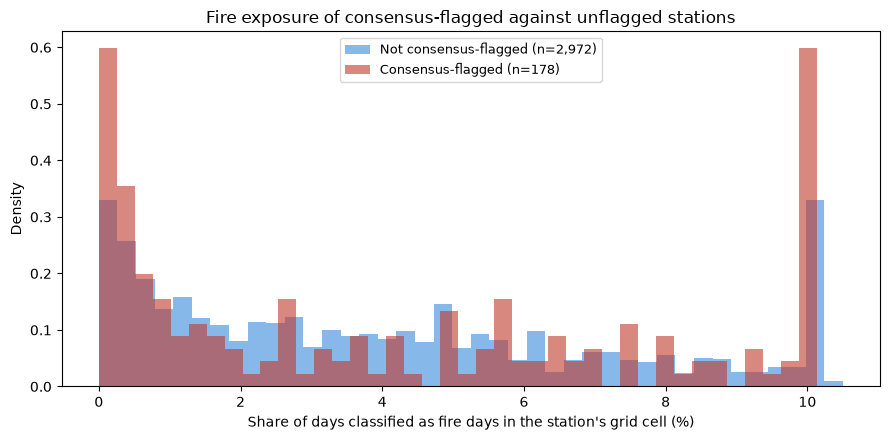

In [22]:
station_exposure = (fire_daily.groupby("cell_id")
                    .agg(fire_days=("is_fire_day", "sum"),
                         days_covered=("fire_date", "nunique"),
                         peak_emission=("pm25_emission_g_per_day", "max"),
                         total_emission=("pm25_emission_g_per_day", "sum"))
                    .reset_index())
station_exposure["fire_day_share_pct"] = (station_exposure["fire_days"] /
                                          station_exposure["days_covered"] * 100).round(2)

stations = stations.merge(station_exposure, on="cell_id", how="left")
stations["consensus_flagged"] = stations["consensus_flagged"].fillna(False).astype(bool)

exposure_comparison = (stations.groupby("consensus_flagged")
                       .agg(stations=("location_id", "size"),
                            median_fire_days=("fire_days", "median"),
                            median_fire_day_share=("fire_day_share_pct", "median"),
                            median_peak_emission=("peak_emission", "median"))
                       .round(3))
display(table_style(exposure_comparison))

fig, ax = plt.subplots(figsize=(9, 4.5))
for flag, label, colour in [(False, "Not consensus-flagged", "#378ADD"),
                            (True, "Consensus-flagged", "#C0392B")]:
    sub = stations.loc[stations["consensus_flagged"] == flag, "fire_day_share_pct"].dropna()
    if len(sub):
        ax.hist(sub, bins=40, alpha=0.6, density=True, label=f"{label} (n={len(sub):,})", color=colour)
ax.set_xlabel("Share of days classified as fire days in the station's grid cell (%)")
ax.set_ylabel("Density")
ax.set_title("Fire exposure of consensus-flagged against unflagged stations")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "gfed5_exposure_by_consensus.png")
plt.show()


<u>Interpretation</u>

If the two distributions are close to indistinguishable, fire exposure is not a systematic
confound for the consensus as a whole — flagged stations are no more fire-prone than any
other, and the flags cannot be explained away collectively even if individual ones can.

If flagged stations sit systematically higher, that is a finding for the report's limitations
rather than a per-station note: it would mean the pipeline is preferentially flagging stations
in fire-affected regions, and the flagged population as a whole would need to be presented with
that qualification attached.


### 7.2 Reconsideration Candidates

Stations combining a consensus flag with substantial fire exposure are listed explicitly. They
are candidates for reconsideration, not reversals: the fire establishes that a competing
explanation exists, not that it is the correct one.


In [23]:
HIGH_EXPOSURE_PERCENTILE = 0.75

exposure_cut = stations["fire_day_share_pct"].quantile(HIGH_EXPOSURE_PERCENTILE)

stations["high_fire_exposure"] = (
    (stations["fire_day_share_pct"] >= exposure_cut) &
    (stations["fire_day_share_pct"] > 0)
)
stations["reconsideration_candidate"] = stations["consensus_flagged"] & stations["high_fire_exposure"]

display(table_style(pd.DataFrame([
    ("High-exposure cutoff (fire-day share %)", round(float(exposure_cut), 2)),
    ("Consensus-flagged stations", int(stations["consensus_flagged"].sum())),
    ("...of which high fire exposure", int(stations["reconsideration_candidate"].sum())),
    ("Share of flagged needing reconsideration (%)",
     round(float(stations.loc[stations["consensus_flagged"], "high_fire_exposure"].mean() * 100), 2)
     if int(stations["consensus_flagged"].sum()) else np.nan),
], columns=["Property", "Value"]).set_index("Property")))

candidates_table = (stations[stations["reconsideration_candidate"]]
                    .sort_values("consensus_rate", ascending=False)
                    [["location_id", "country", "consensus_rank", "consensus_rate",
                      "consensus_direction", "fire_day_share_pct", "peak_emission",
                      "stations_in_cell"]]
                    .head(20).reset_index(drop=True).round(3))
display(table_style(candidates_table))


,Property,Value
0,High-exposure cutoff (fire-day share %),6.300000
1,Consensus-flagged stations,178.000000
2,...of which high fire exposure,56.000000
3,Share of flagged needing reconsideration (%),31.460000


,location_id,country,consensus_rank,consensus_rate,consensus_direction,fire_day_share_pct,peak_emission,stations_in_cell
0,site_5669,India,4.000000,0.800000,SH_over_report,10.050000,185835440.000000,2
1,2709a,China,5.000000,0.714000,SH_over_report,10.050000,73379472.000000,2
2,2710a,China,6.000000,0.714000,SL_under_report,10.050000,73379472.000000,2
3,1492a,China,19.000000,0.600000,SH_over_report,9.320000,34992396.000000,2
4,1459a,China,27.000000,0.500000,SL_under_report,10.050000,74259600.000000,5
5,1496a,China,28.000000,0.500000,SL_under_report,6.390000,69807480.000000,3
6,3441a,China,30.000000,0.500000,SL_under_report,6.390000,69807480.000000,3
7,2711a,China,29.000000,0.500000,none,6.390000,69807480.000000,3
8,site_5664,India,53.000000,0.429000,SL_under_report,10.050000,27889184.000000,1
9,3630a,China,50.000000,0.429000,SH_over_report,7.400000,26326542.000000,1


<u>Interpretation</u>

A station appearing here is one the pipeline ranked as suspicious that also sits where fires
burn often. The `consensus_direction` column sharpens the reading considerably: fire offers a
plausible explanation for a station reading *high*, and essentially none for a station reading
*low*. A high-exposure station flagged for under-reporting is therefore not meaningfully
explained by its fire exposure, and should not be discounted on that basis.

The `stations_in_cell` column carries the caveat from Section 3.2 into the candidate list: a
station sharing its cell with many others inherits that cell's fire exposure without any
evidence the fire was near it specifically.


## 8. Results and Handoff

### 8.1 Cross-Reference Output

Two files are written: per-station fire exposure for every station, and per-episode fire
coincidence for every extreme reading. Both carry the archive provenance, since results
depending on the 2023 Beta data are not on the same footing as those from the stable years.


In [24]:
station_output_columns = [
    "location_id", "country", "latitude", "longitude",
    "cell_id", "cell_lat", "cell_lon", "assignment_offset_km", "stations_in_cell",
    "consensus_rank", "consensus_rate", "consensus_flagged", "consensus_direction",
    "fire_days", "days_covered", "fire_day_share_pct", "peak_emission", "total_emission",
    "high_fire_exposure", "reconsideration_candidate",
]
station_output = stations[station_output_columns].copy()
station_output["gfed5_access_date"] = GFED5_ACCESS_DATE
station_output["includes_beta_2023"] = any(a["name"] == "beta_2023" and archive_files[a["name"]]
                                           for a in GFED5_ARCHIVES)

STATION_OUT_PATH = PROCESSED_DIR / "fire_crossref_station.csv"
station_output.to_csv(STATION_OUT_PATH, index=False)

if len(episode_join):
    episode_output = episode_join[[
        "location_id", "country", "date", "value", "cell_id",
        "consensus_flagged", "consensus_rate", "stations_in_cell",
        "fire_in_window", "peak_emission_in_window",
    ]].copy()
    episode_output["smoke_lag_days"] = SMOKE_LAG_DAYS
    episode_output["gfed5_access_date"] = GFED5_ACCESS_DATE
else:
    episode_output = pd.DataFrame(columns=["location_id", "country", "date", "value"])

EPISODE_OUT_PATH = PROCESSED_DIR / "fire_crossref_episodes.csv"
episode_output.to_csv(EPISODE_OUT_PATH, index=False)

display(table_style(pd.DataFrame([
    ("Station file", STATION_OUT_PATH.name),
    ("Stations written", f"{len(station_output):,}"),
    ("Episode file", EPISODE_OUT_PATH.name),
    ("Episodes written", f"{len(episode_output):,}"),
    ("Reconsideration candidates", int(station_output["reconsideration_candidate"].sum())),
    ("GFED5 access date", GFED5_ACCESS_DATE),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station file,fire_crossref_station.csv
1,Stations written,"3,150"
2,Episode file,fire_crossref_episodes.csv
3,Episodes written,"13,512"
4,Reconsideration candidates,56
5,GFED5 access date,2026-08-12


<u>Interpretation</u>

Every station is written, not only the flagged or fire-exposed ones, so that the unflagged
population remains available as the comparison baseline any later reader would need to check
Section 7.1's conclusion for themselves.


### 8.2 Output Validation



In [25]:
reloaded = pd.read_csv(STATION_OUT_PATH)

checks = pd.DataFrame([
    ("Stations written", len(station_output), len(reloaded), len(station_output) == len(reloaded)),
    ("Unique station IDs", station_output["location_id"].nunique(), reloaded["location_id"].nunique(),
     station_output["location_id"].nunique() == reloaded["location_id"].nunique()),
    ("Fire-day share within [0, 100]", "yes",
     "yes" if reloaded["fire_day_share_pct"].dropna().between(0, 100).all() else "no",
     bool(reloaded["fire_day_share_pct"].dropna().between(0, 100).all())),
    ("Assignment offset under 25 km", "yes",
     "yes" if (reloaded["assignment_offset_km"].dropna() < 25).all() else "no",
     bool((reloaded["assignment_offset_km"].dropna() < 25).all())),
    ("Every reconsideration candidate is consensus-flagged", "yes",
     "yes" if reloaded.loc[reloaded["reconsideration_candidate"], "consensus_flagged"].all() else "no",
     bool(reloaded.loc[reloaded["reconsideration_candidate"], "consensus_flagged"].all())),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(station_output) == len(reloaded), "Row count changed on write."
assert reloaded["fire_day_share_pct"].dropna().between(0, 100).all(), "Fire-day share outside [0, 100]."
assert (reloaded["assignment_offset_km"].dropna() < 25).all(), \
    "A station was assigned to a grid cell further away than the grid geometry permits."
assert reloaded.loc[reloaded["reconsideration_candidate"], "consensus_flagged"].all(), \
    "A reconsideration candidate is not consensus-flagged — the two conditions have come apart."


,Check,Computed,Reloaded,Pass
0,Stations written,3150,3150,True
1,Unique station IDs,3150,3150,True
2,"Fire-day share within [0, 100]",yes,yes,True
3,Assignment offset under 25 km,yes,yes,True
4,Every reconsideration candidate is consensus-flagged,yes,yes,True


<u>Interpretation</u>

The assignment-offset check is the one that would catch a coordinate problem: on a 0.25° grid
no station can legitimately sit more than about 20 km from its nearest cell centre, so a
larger offset means a coordinate outside the grid or mis-parsed rather than a genuine
assignment.


## 9. Findings and Limitations

### Findings

1. **Fire exposure is now testable per station and per episode, not assumed.** <br>Every
station carries a fire-day count derived from its own grid cell's emission distribution, and
every extreme reading carries whether fire burned nearby within a smoke-transport window. The
question of whether a flag has an innocent explanation moves from speculation to a checkable
figure.</br>

2. **The test is deliberately one-directional.** <br>Fire coincidence weakens a suspicion;
its absence does not strengthen one. A station flagged with no nearby fire is not thereby more
likely to be misreporting — it is unexplained by this specific alternative, of which many
others were never tested.</br>

3. **Direction determines whether fire is even a candidate explanation.** <br>Fire plausibly
explains a station reading high and essentially never one reading low. The reconsideration
candidates carry their consensus direction for exactly this reason: a high-exposure station
flagged for under-reporting is not explained by its fire exposure, and the output makes that
visible rather than leaving it to be inferred.</br>

4. **Both GFED5 archives were verified rather than assumed.** <br>Variable names differ
between them (`PM2.5` with a dot in the stable archive, `PM25` without one in the Beta
extension), as does file granularity. Both were confirmed against the downloaded files, and
Section 2.2 re-verifies the shared grid in code so that a mismatch fails loudly rather than
silently misassigning every station.</br>

### Limitations

1. **Emissions are not concentrations.** <br>GFED5 reports mass released per grid cell per
day; the stations measure ambient concentration. No conversion is attempted, because doing it
properly requires an atmospheric dispersion model. This notebook establishes coincidence in
space and time, which is weaker than a quantitative attribution and should not be presented
as one.</br>

2. **Grid resolution is coarse relative to station spacing.** <br>At 0.25° a cell spans
roughly 25–28 km and, in the denser networks, contains many stations. Fire in a cell
establishes fire in the vicinity, not fire adjacent to any particular station; the
`stations_in_cell` column quantifies this per station so the weakness is visible where it
applies most.</br>

3. **The 2023 results rest on Beta data.** <br>The GFED5NRT extension covering 2023 is
documented by its providers as reprocessed episodically as science-quality inputs arrive. The
access date is recorded in both output files, and any 2023 figure should be cited with it,
since the same code run later may produce different numbers from a revised archive.</br>

4. **The fire-day threshold embeds a stated convention.** <br>The 90th-percentile rule and
the absolute floor beneath it are reporting conventions, not derived quantities. Section 5.2
reports the consequences of alternative floors so a reader can see how much the choice
matters, but the adopted value remains a judgement.</br>

5. **Fire is one innocent explanation among several.** <br>Dust storms, industrial incidents,
agricultural burning too small for GFED5 to resolve, and local construction can all produce
genuine excursions that this pipeline would flag and this notebook would not explain. A
station left unexplained here is not thereby suspicious.</br>

6. **Episode coverage is partial by construction.** <br>Only stations recording an extreme
*high* reading appear in the episode analysis. Stations flagged for under-reporting, frozen
values, or digit-pattern anomalies have no episodes at all, and for them only the
station-level exposure in Section 7 applies.</br>

---

### Output

| File | Contents |
|---|---|
| `fire_crossref_station.csv` | Per-station fire exposure, reconsideration status, provenance |
| `fire_crossref_episodes.csv` | Per-episode fire coincidence for extreme readings |

**Next:** manual review of the reconsideration candidates, and incorporation of the
station-level exposure comparison into the report's limitations section.

---

### References

Chen, Y., et al. (2023). Multi-decadal trends and variability in burned area from the fifth
version of the Global Fire Emissions Database. *Earth System Science Data*.

van der Werf, G. R., et al. (2025). Global fire emissions estimates during 1997–2022
(GFED5.1). Zenodo. DOI 10.5281/zenodo.16794692.
